In [2]:
import pandas as pd

In [ ]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name=None)


In [6]:

# Combine both sheets
df = pd.concat(df.values(), ignore_index=True)

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           floa

In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


22.8% of transactions have no CustomerID
Transactions without CustomerID are likely guest checkouts — one-time buyers who didn't create an account.
those transactions are not needed in this analysis

In [11]:
df = df.dropna(subset=['Customer ID'])

In [12]:
returns = df[df['Quantity'] < 0]
df = df[df['Quantity'] > 0]

In [13]:
df = df[df['Price'] > 0]

In [14]:
df['Revenue'] = df['Quantity'] * df['Price']


In [16]:
print(f"Clean dataset: {df.shape}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Clean dataset: (805549, 9)
Unique customers: 5878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [17]:
print(f"Returns removed: {len(returns)}")
print(f"Return rate: {len(returns)/1067371*100:.1f}%")

Returns removed: 18744
Return rate: 1.8%


In [18]:
print(df['Revenue'].describe())
print(df.groupby('Customer ID')['Revenue'].sum().describe())

count    805549.000000
mean         22.026505
std         224.041928
min           0.001000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64
count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: Revenue, dtype: float64


Someone spent $608,821 total
Someone made a single $168,469 transaction

Median customer spends $898
But mean is $3,018 — 3x higher

This means a tiny number of customers
are pulling the average way up

These are almost certainly wholesale B2B buyers — not regular retail customers. They'll completely distort CLV model if left.

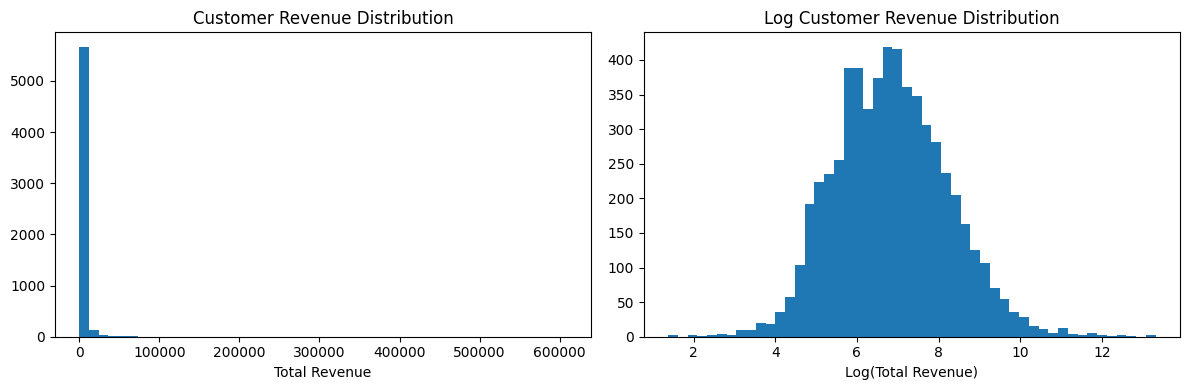

In [19]:
import matplotlib.pyplot as plt
import numpy as np

customer_revenue = df.groupby('Customer ID')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before log transform
axes[0].hist(customer_revenue, bins=50)
axes[0].set_title('Customer Revenue Distribution')
axes[0].set_xlabel('Total Revenue')

# After log transform
axes[1].hist(np.log1p(customer_revenue), bins=50)
axes[1].set_title('Log Customer Revenue Distribution')
axes[1].set_xlabel('Log(Total Revenue)')

plt.tight_layout()
plt.show()

In [20]:
import numpy as np

customer_revenue = df.groupby(
    'Customer ID')['Revenue'].sum()

# Check percentiles
percentiles = [90, 95, 99, 99.5]
for p in percentiles:
    val = np.percentile(customer_revenue, p)
    count = len(customer_revenue[
        customer_revenue > val])
    print(f"P{p}: ${val:,.0f} — "
          f"{count} customers above this")

P90: $5,595 — 588 customers above this
P95: $9,535 — 294 customers above this
P99: $29,730 — 59 customers above this
P99.5: $56,984 — 30 customers above this


59 customers out of 5,878 = 1%
Small enough to not lose meaningful data
Large enough to remove wholesale distortion

In [21]:
# Set threshold
threshold = np.percentile(customer_revenue, 99)

valid_customers = customer_revenue[
    customer_revenue <= threshold].index



In [22]:
df = df[df['Customer ID'].isin(valid_customers)]

print(f"Customers remaining: {df['Customer ID'].nunique()}")
print(f"Transactions remaining: {df.shape[0]}")
print(f"Removed: {5878 - df['Customer ID'].nunique()} outlier customers")

Customers remaining: 5819
Transactions remaining: 707072
Removed: 59 outlier customers


In [23]:
from datetime import timedelta

In [24]:
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")


Snapshot date: 2011-12-10 12:50:00


In [25]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', 
                 lambda x: (snapshot_date - 
                 x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

In [26]:
print(rfm.shape)
print(rfm.describe())
print(rfm.head(10))

(5819, 4)
        Customer ID      Recency    Frequency      Monetary
count   5819.000000  5819.000000  5819.000000   5819.000000
mean   15316.874549   202.888641     5.531535   2075.326280
std     1714.666264   209.486070     7.437132   3366.489414
min    12347.000000     1.000000     1.000000      2.950000
25%    13835.500000    26.000000     1.000000    344.680000
50%    15318.000000    99.000000     3.000000    875.970000
75%    16799.500000   381.000000     7.000000   2228.245000
max    18287.000000   739.000000   122.000000  29532.450000
   Customer ID  Recency  Frequency  Monetary
0      12347.0        2          8   5633.32
1      12348.0       75          5   2019.40
2      12349.0       19          4   4428.69
3      12350.0      310          1    334.40
4      12351.0      375          1    300.93
5      12352.0       36         10   2849.84
6      12353.0      204          2    406.76
7      12354.0      232          1   1079.40
8      12355.0      214          2    947.61


Median customer:
→ Last bought 99 days ago
→ Made 3 purchases total
→ Spent $875 total

In [27]:
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np

In [28]:
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

In [29]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 
                          q=5, 
                          labels=[5,4,3,2,1])

In [30]:
rfm['F_score'] = pd.qcut(rfm['Frequency']
                          .rank(method='first'), 
                          q=5, 
                          labels=[1,2,3,4,5])

In [31]:
rfm['M_score'] = pd.qcut(rfm['Monetary_log'], 
                          q=5, 
                          labels=[1,2,3,4,5])

In [32]:
rfm['RFM_score'] = (rfm['R_score'].astype(int) + 
                    rfm['F_score'].astype(int) + 
                    rfm['M_score'].astype(int))

In [34]:
print(rfm[['Customer ID','R_score', 'F_score','M_score', 'RFM_score']].head(10))
print(f"\nRFM Score range: {rfm['RFM_score'].min()} to {rfm['RFM_score'].max()}")
print(rfm['RFM_score'].describe())

   Customer ID R_score F_score M_score  RFM_score
0      12347.0       5       4       5         14
1      12348.0       3       4       4         11
2      12349.0       5       3       5         13
3      12350.0       2       1       2          5
4      12351.0       2       1       2          5
5      12352.0       4       5       4         13
6      12353.0       2       2       2          6
7      12354.0       2       1       3          6
8      12355.0       2       2       3          7
9      12356.0       4       4       5         13

RFM Score range: 3 to 15
count    5819.000000
mean        9.005499
std         3.631388
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_score, dtype: float64


Verifying Customer 12347 from data:
Recency   → 2 days
Frequency → 8 transactions
Monetary  → $5,633

Customer 12347 makes sense:
Recency → 2 days → R score 5 ✅
          (bought very recently)

Frequency → 8 transactions → F score 4 ✅
            (above average buyer)

Monetary → $5,633 → M score 5 ✅
           (high spender)

RFM Total → 14 → High Value ✅

In [35]:
def assign_tier(score):
    if score >= 12:
        return 'High Value'
    elif score >= 7:
        return 'Mid Value'
    else:
        return 'At Risk'

In [36]:
rfm['CLV_Tier'] = rfm['RFM_score'].apply(assign_tier)

In [37]:
print(rfm['CLV_Tier'].value_counts())
print(rfm['CLV_Tier'].value_counts(normalize=True)*100)

CLV_Tier
Mid Value     2367
At Risk       1747
High Value    1705
Name: count, dtype: int64
CLV_Tier
Mid Value     40.677092
At Risk       30.022341
High Value    29.300567
Name: proportion, dtype: float64


In [38]:
print(rfm.groupby('CLV_Tier').agg(
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Count         = ('Customer ID', 'count')
).round(2))

            Avg_Recency  Avg_Frequency  Avg_Monetary  Count
CLV_Tier                                                   
At Risk          411.75           1.24        302.72   1747
High Value        36.73          12.82       5188.27   1705
Mid Value        168.43           3.45       1141.30   2367


Insights:

High Value customers buy 10x more frequently, visit 11x more recently, and spend 17x more than At Risk customers.

Recancy gap is high:
High Value → bought 37 days ago
At Risk    → bought 412 days ago
Gap        → 375 days = over 1 year

High Value buys 12.8x vs At Risk 1.2x
That's 10x more frequent
Confirms your hypothesis — 
frequency is the strongest differentiator


High Value  → $5,188
At Risk     → $303
17x difference in spend

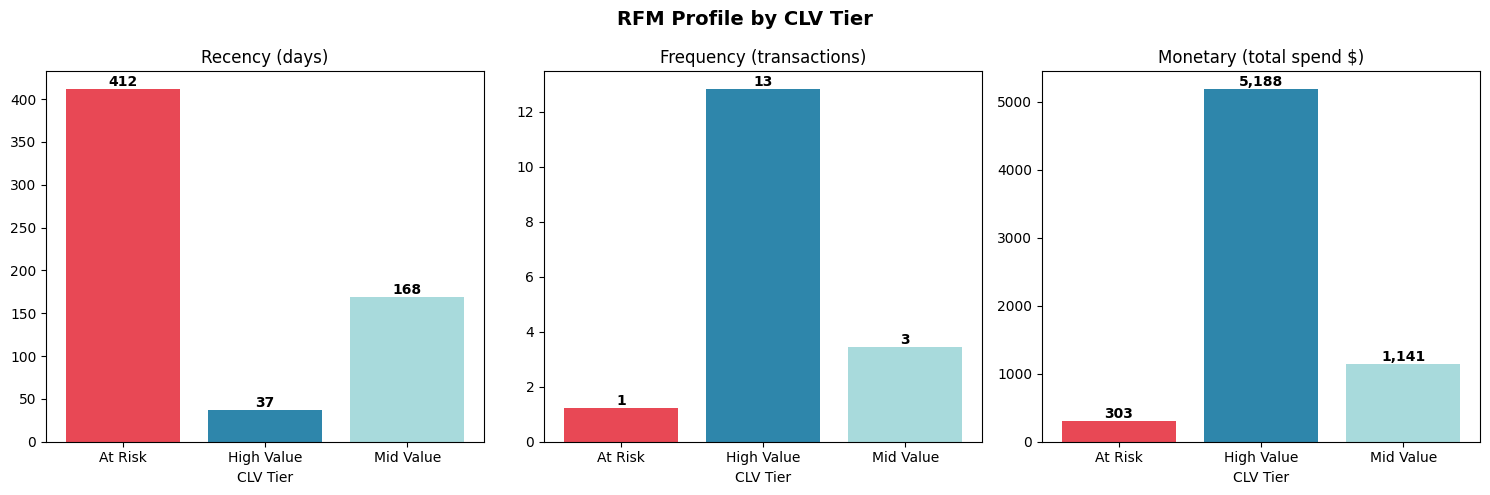

In [41]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency (days)', 
          'Frequency (transactions)', 
          'Monetary (total spend $)']
colors = {'High Value': '#2E86AB', 
          'Mid Value': '#A8DADC', 
          'At Risk': '#E84855'}

for i, (metric, title) in enumerate(
    zip(metrics, titles)):
    
    data = rfm.groupby('CLV_Tier')[metric].mean()
    bars = axes[i].bar(data.index, 
                       data.values,
                       color=[colors[t] 
                              for t in data.index])
    axes[i].set_title(title)
    axes[i].set_xlabel('CLV Tier')
    
    for bar, val in zip(bars, data.values):
        axes[i].text(bar.get_x() + 
                     bar.get_width()/2,
                     bar.get_height(),
                     f'{val:,.0f}',
                     ha='center', va='bottom',
                     fontweight='bold')

plt.suptitle('RFM Profile by CLV Tier', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb

In [ ]:
features = ['Recency', 'Frequency', 'Monetary', 'Monetary_log']

X = rfm[features]
y = rfm['CLV_Tier']

In [44]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

Classes: ['At Risk' 'High Value' 'Mid Value']


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded)

In [46]:
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (4655, 4)
Test size: (1164, 4)


In [47]:

train_dist = pd.Series(y_train).value_counts(
    normalize=True)*100
test_dist = pd.Series(y_test).value_counts(
    normalize=True)*100

print("Train distribution:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {train_dist[i]:.1f}%")

print("\nTest distribution:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {test_dist[i]:.1f}%")

Train distribution:
  At Risk: 30.0%
  High Value: 29.3%
  Mid Value: 40.7%

Test distribution:
  At Risk: 30.0%
  High Value: 29.3%
  Mid Value: 40.7%


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix)

In [49]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

In [50]:
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [51]:
y_pred_xgb = xgb_model.predict(X_test)

In [52]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=le.classes_))

XGBoost Accuracy: 0.9596

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.95      0.95      0.95       349
  High Value       0.98      0.98      0.98       341
   Mid Value       0.95      0.95      0.95       474

    accuracy                           0.96      1164
   macro avg       0.96      0.96      0.96      1164
weighted avg       0.96      0.96      0.96      1164



In [53]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbose=-1
)


In [54]:
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

In [55]:
lgb_accuracy = accuracy_score(y_test, y_pred_lgb)
print(f"LightGBM Accuracy: {lgb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb,
      target_names=le.classes_))

LightGBM Accuracy: 0.9588

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.95      0.94      0.94       349
  High Value       0.99      0.99      0.99       341
   Mid Value       0.95      0.95      0.95       474

    accuracy                           0.96      1164
   macro avg       0.96      0.96      0.96      1164
weighted avg       0.96      0.96      0.96      1164



In [56]:
print(f"\nModel Comparison:")
print(f"XGBoost  → {xgb_accuracy:.4f}")
print(f"LightGBM → {lgb_accuracy:.4f}")


Model Comparison:
XGBoost  → 0.9596
LightGBM → 0.9588


In [57]:
from sklearn.ensemble import VotingClassifier

In [58]:
xgb_proba = xgb_model.predict_proba(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

ensemble_proba = (xgb_proba + lgb_proba) / 2

y_pred_ensemble = np.argmax(ensemble_proba, axis=1)

ensemble_accuracy = accuracy_score(
    y_test, y_pred_ensemble)

In [59]:
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")
print(f"\nModel Comparison:")
print(f"XGBoost  → {xgb_accuracy:.4f}")
print(f"LightGBM → {lgb_accuracy:.4f}")
print(f"Ensemble → {ensemble_accuracy:.4f}")

print("\nEnsemble Classification Report:")
print(classification_report(y_test, 
      y_pred_ensemble,
      target_names=le.classes_))

Ensemble Accuracy: 0.9605

Model Comparison:
XGBoost  → 0.9596
LightGBM → 0.9588
Ensemble → 0.9605

Ensemble Classification Report:
              precision    recall  f1-score   support

     At Risk       0.95      0.95      0.95       349
  High Value       0.99      0.98      0.98       341
   Mid Value       0.95      0.96      0.95       474

    accuracy                           0.96      1164
   macro avg       0.96      0.96      0.96      1164
weighted avg       0.96      0.96      0.96      1164



In [60]:
import shap

In [61]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

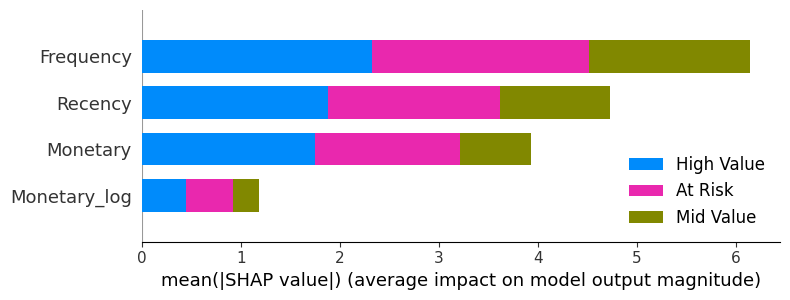

In [62]:
shap.summary_plot(shap_values, 
                  X_test,
                  feature_names=features,
                  class_names=le.classes_,
                  plot_type='bar')

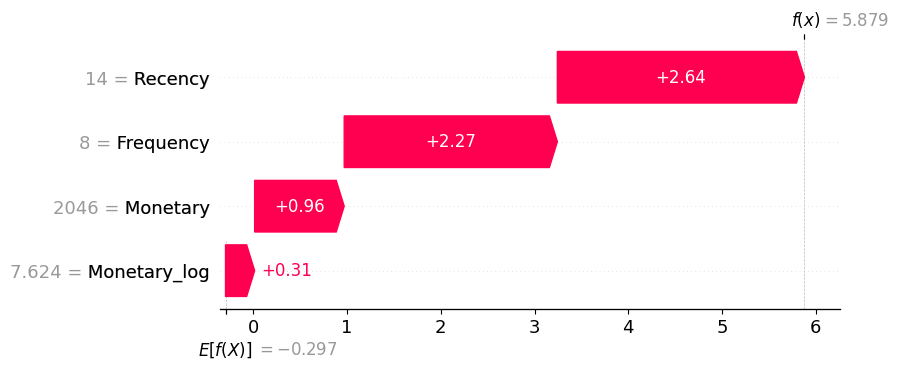

In [ ]:
hv_idx = list(le.classes_).index('High Value')

sample_idx = np.where(y_test == hv_idx)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx, :, hv_idx],
        base_values=explainer.expected_value[hv_idx],
        data=X_test.iloc[sample_idx],
        feature_names=features
    )
)

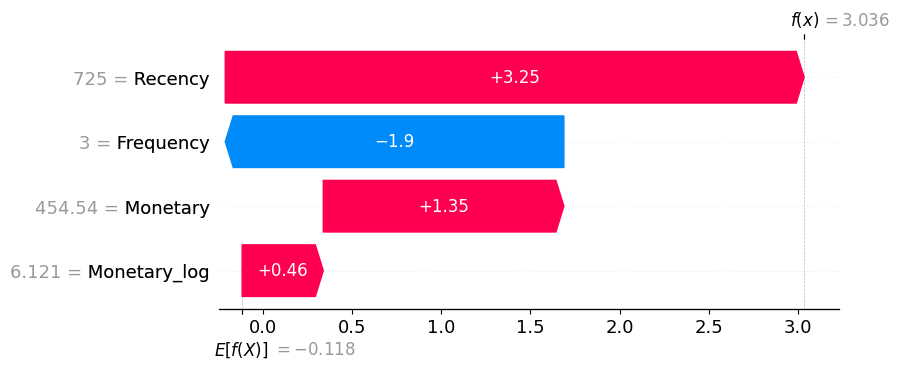

In [ ]:
ar_idx = list(le.classes_).index('At Risk')
sample_idx_ar = np.where(y_test == ar_idx)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx_ar, :, ar_idx],
        base_values=explainer.expected_value[ar_idx],
        data=X_test.iloc[sample_idx_ar],
        feature_names=features
    )
)

In [ ]:
output = rfm[['Customer ID', 'Recency', 
              'Frequency', 'Monetary', 
              'RFM_score', 'CLV_Tier']]


rfm_test = rfm.iloc[X_test.index]
output_test = output.iloc[X_test.index].copy()
output_test['Predicted_Tier'] = le.inverse_transform(
    y_pred_ensemble)


output_test.to_csv('clv_predictions.csv', index=False)
print(output_test.head(10))
print(f"\nSaved {len(output_test)} predictions")

      Customer ID  Recency  Frequency  Monetary  RFM_score    CLV_Tier  \
4625      17067.0      725          3    454.54          6     At Risk   
446       12801.0      501          1   1071.82          5     At Risk   
1847      14237.0      373          2    632.14          7   Mid Value   
308       12658.0       19          1    686.05          9   Mid Value   
3062      15473.0       14          8   2046.00         14  High Value   
270       12620.0       15          3   1339.41         12  High Value   
1357      13734.0      509          4   6701.64          9   Mid Value   
186       12536.0       43          3  12601.83         12  High Value   
373       12727.0       11         10   5679.53         15  High Value   
3379      15793.0       15          8   2399.57         14  High Value   

     Predicted_Tier  
4625        At Risk  
446         At Risk  
1847      Mid Value  
308       Mid Value  
3062     High Value  
270      High Value  
1357      Mid Value  
186      